In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt

import env.trading_env as te
import features.feature_engineering as fe
importlib.reload(te)
importlib.reload(fe)

from stable_baselines3 import A2C
from stable_baselines3.common.callbacks import BaseCallback

In [2]:
# Read data
df = pd.read_excel('../data/data.xlsx', skiprows=6, header=0)
df.columns = ['date', 'gold', 'silver', 'copper']
df = df[pd.to_datetime(df['date'], errors='coerce').notna()]
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [3]:
# Feature engineering
features_final = fe.build_features(df)

# Split
train = features_final[features_final.index <= '2023-12-31']
test = features_final[features_final.index >= '2024-01-01']
price_train = df[df.index.isin(train.index)]
price_test = df[df.index.isin(test.index)]

print(f"Train: {len(train)}days, Test: {len(test)}days")

Train: 2592days, Test: 485days


finish training


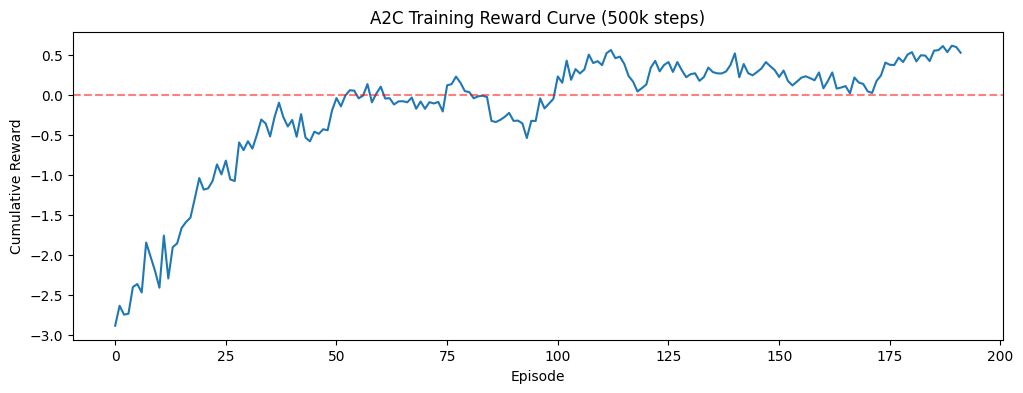

Average reward for the last 10 episodes: 0.5424


In [4]:
class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.current_rewards = []
    
    def _on_step(self):
        reward = self.locals['rewards'][0]
        self.current_rewards.append(reward)
        
        if self.locals['dones'][0]:
            self.episode_rewards.append(sum(self.current_rewards))
            self.current_rewards = []
        return True

# Set up the environment
train_env = te.MetalTradingEnv(train, price_train)
callback_a2c500k = RewardCallback()

model_a2c500k = A2C(
    "MlpPolicy",
    train_env,
    learning_rate=7e-4,
    n_steps=5,
    gamma=0.99,
    verbose=0
)

model_a2c500k.learn(total_timesteps=500_000, callback=callback_a2c500k)
print("finish training")



# plot
plt.figure(figsize=(12, 4))
plt.plot(callback_a2c500k.episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("A2C Training Reward Curve (500k steps)")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.show()

print(f"Average reward for the last 10 episodes: {sum(callback_a2c500k.episode_rewards[-10:])/10:.4f}")

In [ ]:
# Save
model_a2c.save("../agents/a2c_metal_500k")
np.save("../agents/a2c_rewards_500k.npy", callback_a2c.episode_rewards)

finish training


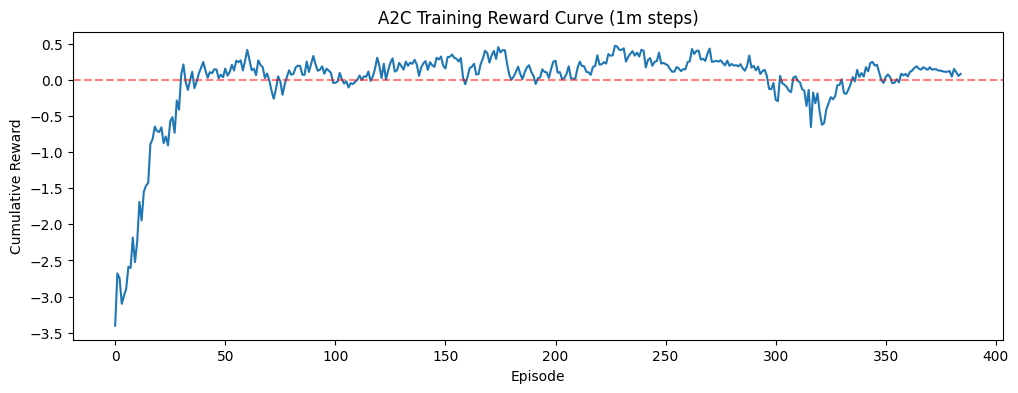

Average reward for the last 10 episodes: 0.1058


In [5]:
# Set up the environment
train_env = te.MetalTradingEnv(train, price_train)
callback_a2c1m = RewardCallback()

model_a2c1m = A2C(
    "MlpPolicy",
    train_env,
    learning_rate=7e-4,
    n_steps=5,
    gamma=0.99,
    verbose=0
)

model_a2c1m.learn(total_timesteps=1_000_000, callback=callback_a2c1m)
print("finish training")



# plot
plt.figure(figsize=(12, 4))
plt.plot(callback_a2c1m.episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("A2C Training Reward Curve (1m steps)")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.show()

print(f"Average reward for the last 10 episodes: {sum(callback_a2c1m.episode_rewards[-10:])/10:.4f}")

In [7]:
# Save
model_a2c1m.save("../agents/a2c_step_1m")
np.save("../agents/a2c_rewards_1m.npy", callback_a2c1m.episode_rewards)

finish training


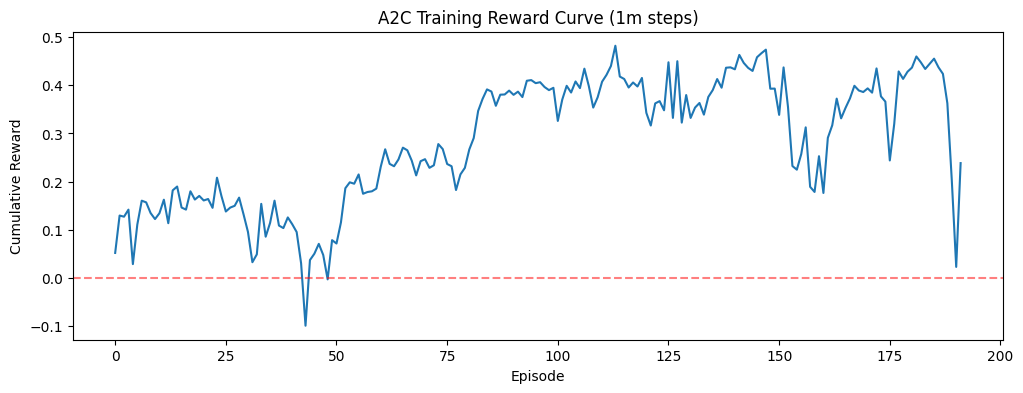

Average reward for the last 10 episodes: 0.3468


In [8]:
model_a2c1500k = A2C.load("../agents/a2c_step_1m", env=train_env)

train_env = te.MetalTradingEnv(train, price_train)
callback_a2c1500k = RewardCallback()

model_a2c1500k.learn(total_timesteps=500_000, callback=callback_a2c1500k)
print("finish training")

# plot
plt.figure(figsize=(12, 4))
plt.plot(callback_a2c1500k.episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("A2C Training Reward Curve (1m steps)")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.show()

print(f"Average reward for the last 10 episodes: {sum(callback_a2c1500k.episode_rewards[-10:])/10:.4f}")

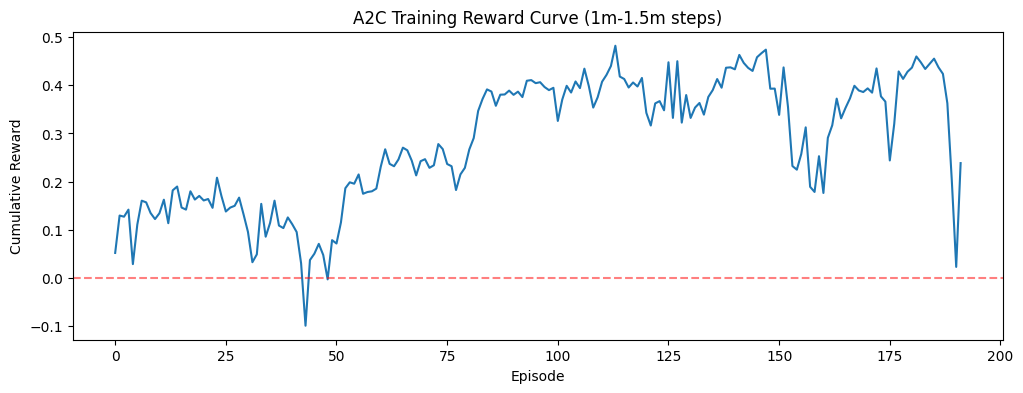

Average reward for the last 10 episodes: 0.3468


In [9]:
# plot
plt.figure(figsize=(12, 4))
plt.plot(callback_a2c1500k.episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("A2C Training Reward Curve (1m-1.5m steps)")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.show()

print(f"Average reward for the last 10 episodes: {sum(callback_a2c1500k.episode_rewards[-10:])/10:.4f}")

In [10]:
# Save
model_a2c1m.save("../agents/a2c_step_1500k")
np.save("../agents/a2c_rewards_1500k.npy", callback_a2c1m.episode_rewards)

In [1]:
import os
files = os.listdir('../agents/')
print(files)

['.gitkeep', 'a2c_rewards_1500k.npy', 'a2c_rewards_1m.npy', 'a2c_step_1500k.zip', 'a2c_step_1m.zip', 'ppo_step_1500k.zip', 'ppo_step_1m.npy', 'ppo_step_1m.zip', 'ppo_step_500k.npy', 'ppo_step_500k.zip', 'sac_rewards_1m.npy', 'sac_rewards_700k.npy', 'sac_step_1m.zip', 'sac_step_500k.npy', 'sac_step_500k.zip', 'sac_step_700k.zip', 'train.py']


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 加载1m的reward数据
ppo_rewards = np.load('../agents/ppo_step_1m.npy')

a2c_rewards = np.load('../agents/a2c_rewards_1m.npy')

sac_500k = np.load('../agents/sac_step_500k.npy')
sac_1m = np.load('../agents/sac_rewards_1m.npy')
sac_rewards = np.concatenate([sac_500k, sac_1m])

print(f"PPO episodes: {len(ppo_rewards)}")
print(f"SAC episodes: {len(sac_rewards)}")
print(f"A2C episodes: {len(a2c_rewards)}")

PPO episodes: 386
SAC episodes: 384
A2C episodes: 385


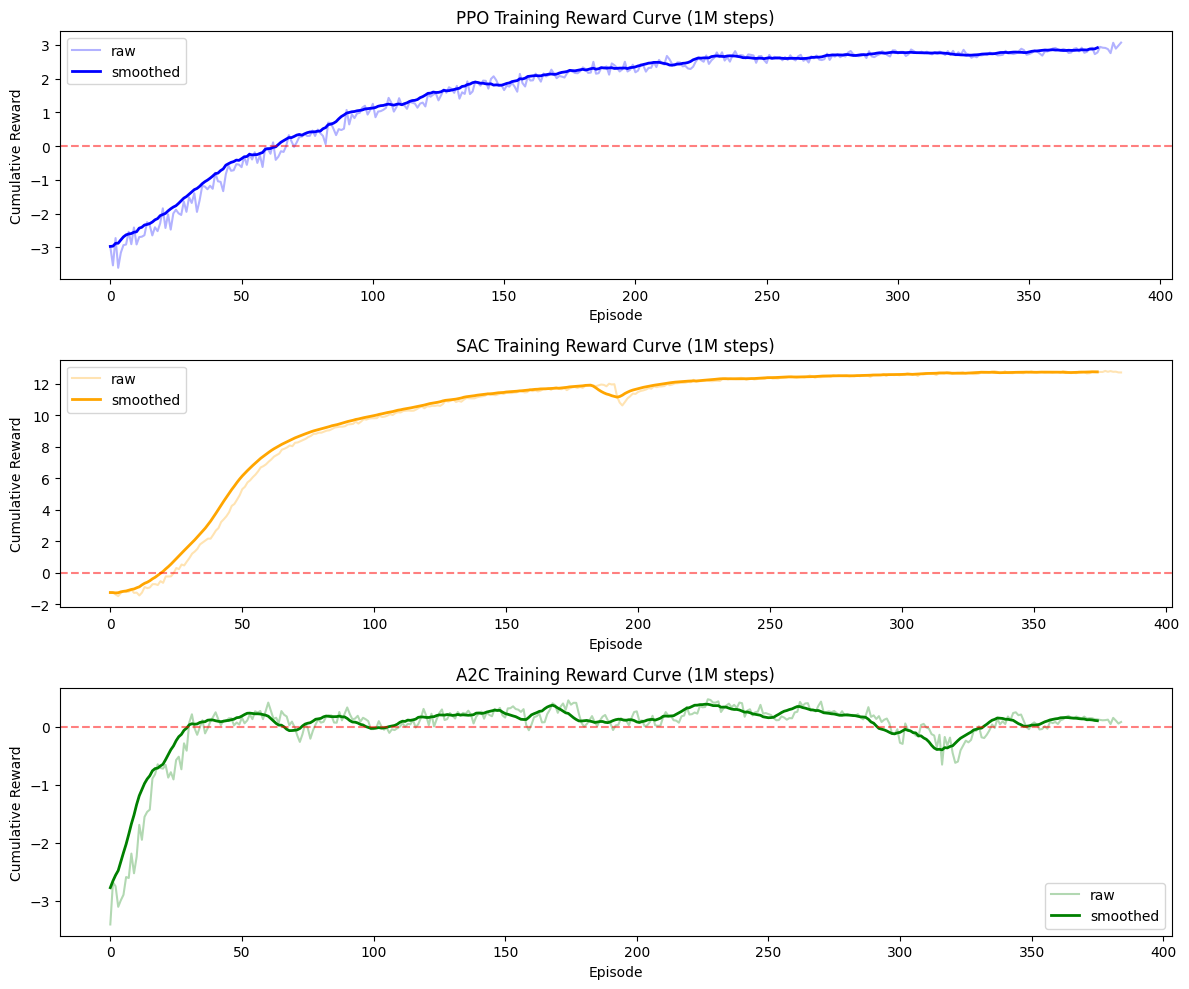

Average reward for the final 10 episodes of PPO: 2.9199
Average reward for the final 10 episodes of SAC: 12.7665
Average reward for the final 10 episodes of A2C: 0.1058


In [4]:
def smooth(rewards, window=10):
    return np.convolve(rewards, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

algorithms = [
    ('PPO', ppo_rewards, 'blue'),
    ('SAC', sac_rewards, 'orange'),
    ('A2C', a2c_rewards, 'green')
]

for ax, (name, rewards, color) in zip(axes, algorithms):
    ax.plot(rewards, alpha=0.3, color=color, label='raw')
    ax.plot(smooth(rewards), color=color, linewidth=2, label='smoothed')
    ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    ax.set_title(f'{name} Training Reward Curve (1M steps)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Cumulative Reward')
    ax.legend()

plt.tight_layout()
plt.savefig('../agents/training_curves_1m.png', dpi=150)
plt.show()

print(f"Average reward for the final 10 episodes of PPO: {np.mean(ppo_rewards[-10:]):.4f}")
print(f"Average reward for the final 10 episodes of SAC: {np.mean(sac_rewards[-10:]):.4f}")
print(f"Average reward for the final 10 episodes of A2C: {np.mean(a2c_rewards[-10:]):.4f}")

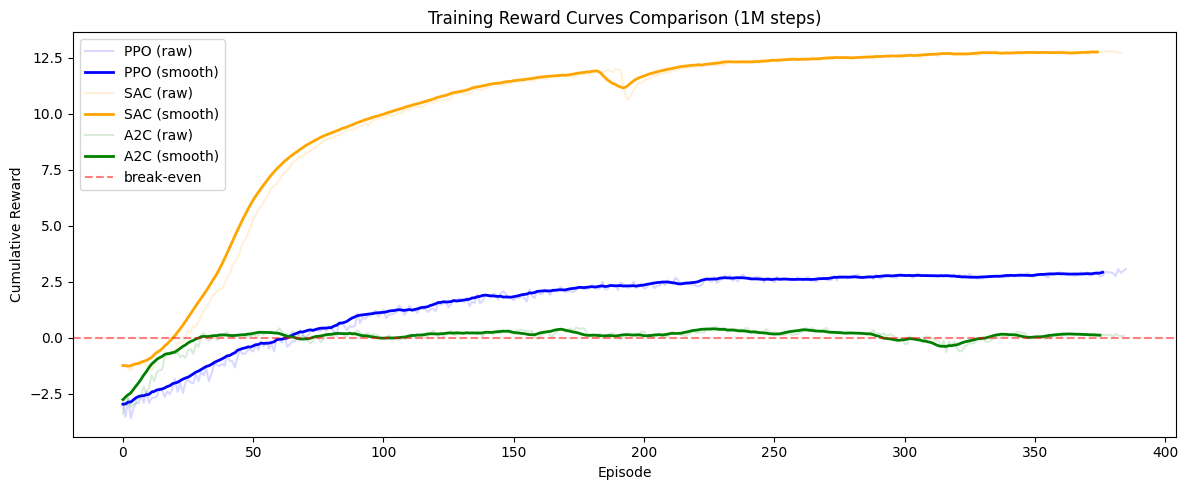

Average reward for the final 10 episodes of PPO: 2.9199
Average reward for the final 10 episodes of SAC: 12.7665
Average reward for the final 10 episodes of A2C: 0.1058


In [6]:
def smooth(rewards, window=10):
    return np.convolve(rewards, np.ones(window)/window, mode='valid')

fig, ax = plt.subplots(figsize=(12, 5))

algorithms = [
    ('PPO', ppo_rewards, 'blue'),
    ('SAC', sac_rewards, 'orange'),
    ('A2C', a2c_rewards, 'green')
]

for name, rewards, color in algorithms:
    
    ax.plot(rewards, alpha=0.15, color=color, label=f'{name} (raw)')
    
    ax.plot(smooth(rewards), color=color, linewidth=2, label=f'{name} (smooth)')

ax.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='break-even')
ax.set_title('Training Reward Curves Comparison (1M steps)')
ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Reward')
ax.legend()

plt.tight_layout()
plt.savefig('../agents/training_curves_comparison.png', dpi=150)
plt.show()

print(f"Average reward for the final 10 episodes of PPO: {np.mean(ppo_rewards[-10:]):.4f}")
print(f"Average reward for the final 10 episodes of SAC: {np.mean(sac_rewards[-10:]):.4f}")
print(f"Average reward for the final 10 episodes of A2C: {np.mean(a2c_rewards[-10:]):.4f}")